# CivilComments quickstart

Toxicity detection from Shanmugam et al., NeurIPS 2025. Seven released classifiers are estimated from 20 visible labels and 1,000 unlabeled comments.

The interactive report for one package fit is [results/report/report.html](results/report/report.html). The two figures use the official half-split protocol from `experiments/civilcomments/reproduce_official_split.py`: 50 seeds, the public 20-epoch EM, and ground truth on the held-out half of the comments.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def package_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents, here / 'ssme-lite']:
        if (candidate / 'ssme_lite' / 'benchmark.py').is_file():
            return candidate
    raise FileNotFoundError('Open this notebook from the ssme-lite repository.')

ROOT = package_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ssme_lite import SSMEEstimator, SemiSupervisedSplit
from ssme_lite.benchmark import official_scores
DATA = ROOT.parent / 'official' / 'SSME' / 'inputs'
BENCHMARK = ROOT.parent / 'results' / 'civilcomments_official_kde_benchmark'
OUT = ROOT / 'experiments' / 'civilcomments' / 'results'
scores, y, names = official_scores(DATA, 'CivilComments')
print(f'{scores.shape[0]} comments, {scores.shape[1]} models, {int(y.sum())} toxic labels')

133782 comments, 7 models, 15224 toxic labels


## One split, one report

`max_iter` is the EM epoch count. This package fit uses 20 epochs and `bandwidth="official"`. It draws 20 labels and 1,000 unlabeled comments from the full release and holds out the rest. The figures below are a separate 50-seed run of the public code on the half split.

`random_state=0` fixes this draw. The page intervals are latent-label uncertainty given this fit, not standard errors across seeds.


In [2]:
splitter = SemiSupervisedSplit(n_labeled=20, n_unlabeled=1000, random_state=0)
parts = splitter.indices(len(y))
if splitter.labeled_class_count(y, parts) != scores.shape[-1]:
    raise RuntimeError('labeled draw missed a class')
estimator = SSMEEstimator(max_iter=20, early_stopping=False, bandwidth='official', random_state=0)
estimator.fit(scores[parts['estimation']], splitter.partial_labels(y, parts), model_names=names)
report = estimator.report(
    n_draws=100,
    title='CivilComments',
    primary_metric='accuracy',
    sample_ids=parts['estimation'],
)
report.save(OUT / 'report')
ranking = report.ranking('accuracy')
print(ranking.to_string(index=False))
print(OUT / 'report' / 'report.html')

        model   metric  estimate    label_std  mc_standard_error  interval_low  interval_high  valid_draws  rank
alg_ERM_seed2 accuracy  0.947059 3.347448e-16                0.0      0.947059       0.947059          100   1.0
alg_ERM_seed1 accuracy  0.945098 2.231632e-16                0.0      0.945098       0.945098          100   2.0
      alg_ERM accuracy  0.942157 2.231632e-16                0.0      0.942157       0.942157          100   3.0
alg_IRM_seed1 accuracy  0.936275 0.000000e+00                0.0      0.936275       0.936275          100   4.0
alg_IRM_seed2 accuracy  0.931373 3.347448e-16                0.0      0.931373       0.931373          100   5.0
      alg_IRM accuracy  0.926471 2.231632e-16                0.0      0.926471       0.926471          100   6.0
    alg_CORAL accuracy  0.863725 4.463264e-16                0.0      0.863725       0.863725          100   7.0
/Users/jason/Desktop/研一上/机器学习与 Python 应用/ssme-lite/experiments/civilcomments/results/report/repo

## How the estimates compare with holdout labels

The left figure is relative mean absolute error on the seven released models. RMAE divides each method's held-out error by the labeled-only error, so the dashed line at 1 is that baseline. Majority Vote, PL, and Dawid-Skene follow Appendix B.2.

The right figure is the same SSME-versus-labeled comparison in percentage points, for AUC and Accuracy. The last three rows are score mixtures. They are scored with the labels SSME imputes from the seven released models.


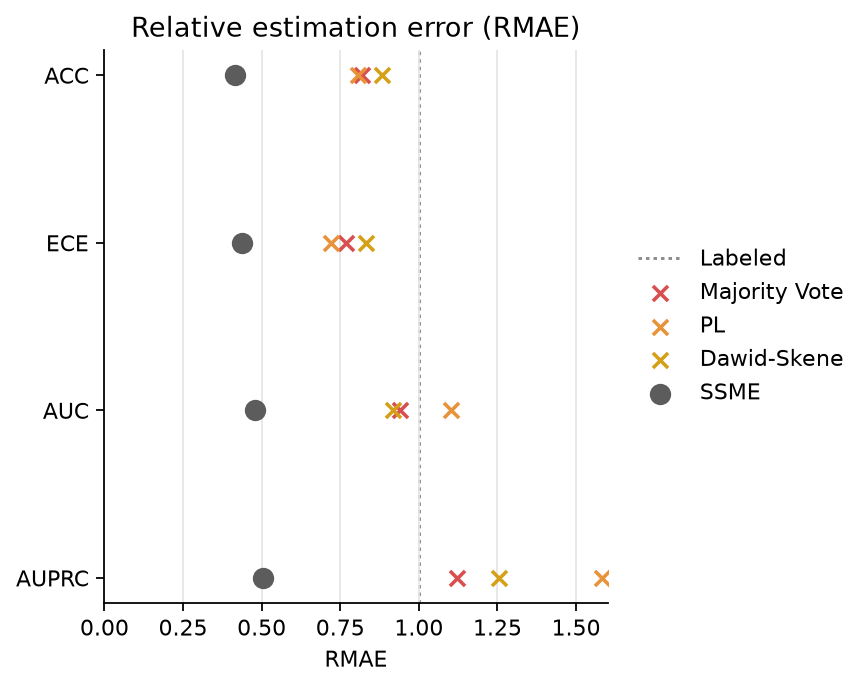

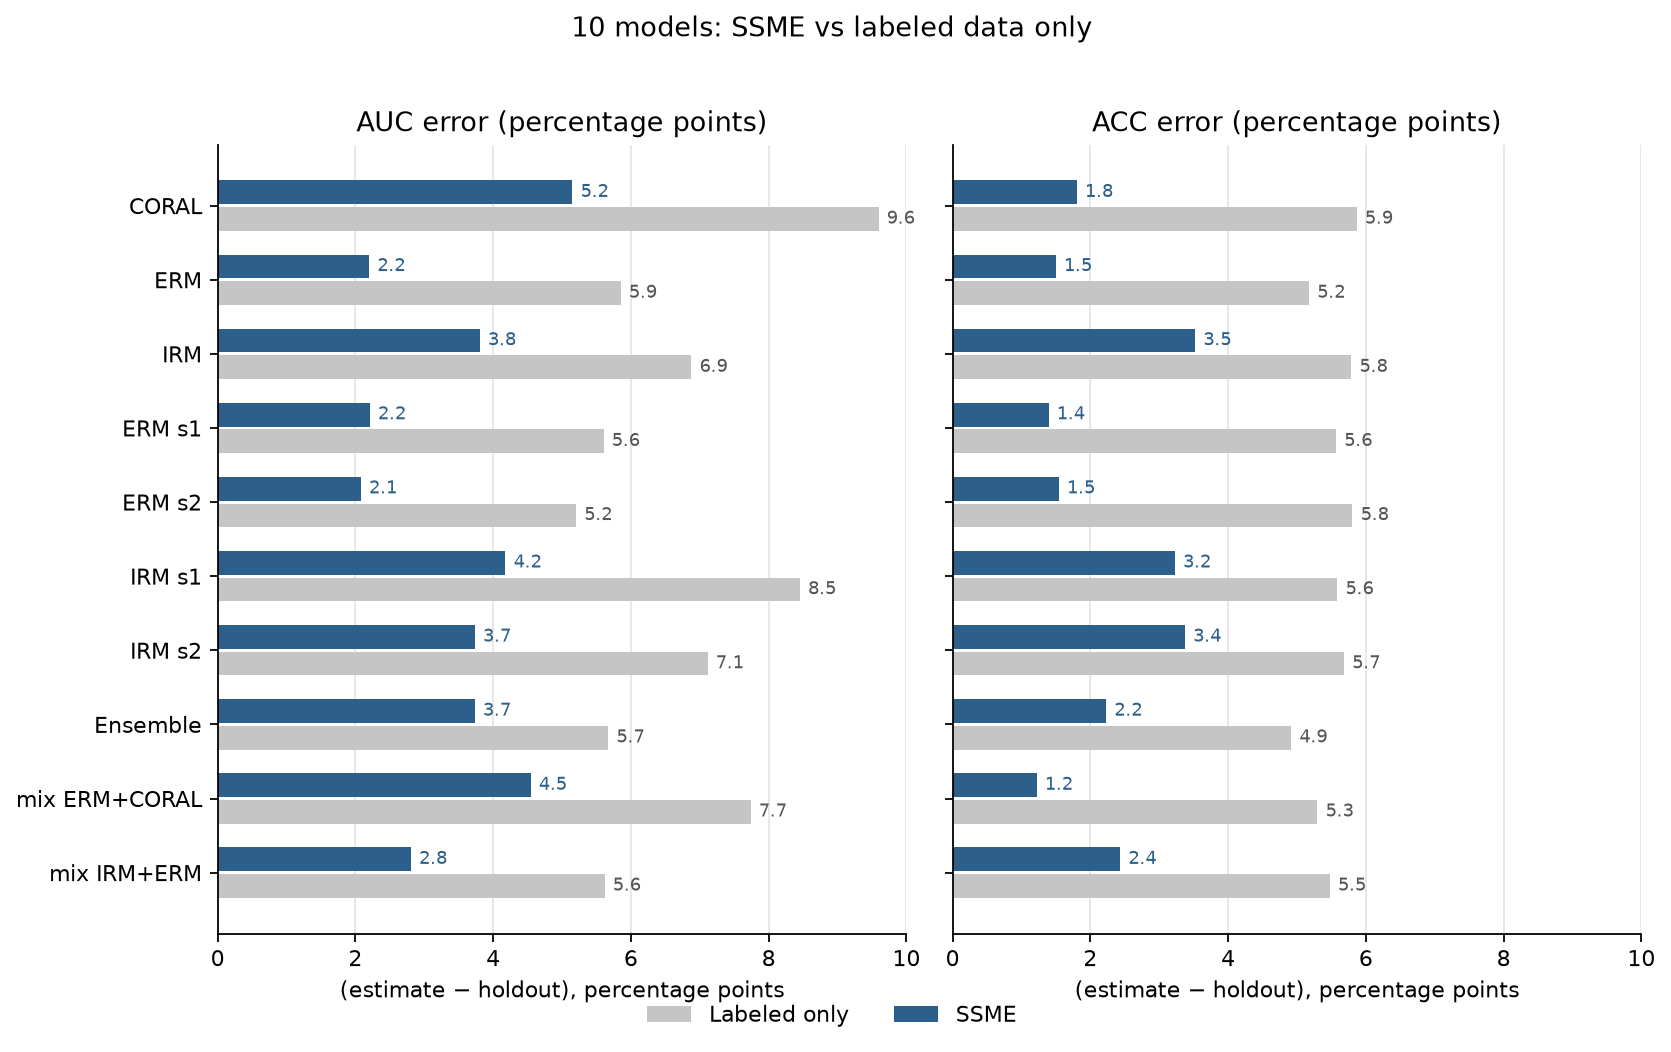

In [3]:
import importlib.util
from IPython.display import Image, display

script = ROOT / 'experiments' / 'civilcomments' / 'reproduce_official_split.py'
details = ROOT.parent / 'results' / 'civilcomments_official_split' / 'details.csv'
if not details.is_file():
    raise FileNotFoundError('Run python experiments/civilcomments/reproduce_official_split.py first.')
spec = importlib.util.spec_from_file_location('reproduce_official_split', script)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)
module.plot(details, OUT)
display(Image(filename=str(OUT / 'rmae.png')))
display(Image(filename=str(OUT / 'model_errors.png')))
